In [6]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from sklearn.model_selection import train_test_split
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.frozen import FrozenEstimator
from sklearn.metrics import roc_auc_score, brier_score_loss
from lightgbm import LGBMClassifier

from src.features import build_features

X, y = build_features()

categorical_features = X.select_dtypes(include=['object', 'string']).columns.tolist()
for col in categorical_features:
    X[col] = X[col].astype('category')

print(f"Shape: {X.shape}, categoricals: {len(categorical_features)}")

Shape: (307511, 142), categoricals: 16


In [7]:
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

X_train, X_cal, y_train, y_cal = train_test_split(
    X_trainval, y_trainval, test_size=0.2, stratify=y_trainval, random_state=42)

print(f"Train: {X_train.shape[0]}, Calibration: {X_cal.shape[0]}, Test: {X_test.shape[0]}")

Train: 196806, Calibration: 49202, Test: 61503


In [8]:
model = LGBMClassifier(
    n_estimators=500, learning_rate=0.05, num_leaves=31,
    class_weight="balanced", random_state=42, verbose=-1)

model.fit(X_train, y_train, categorical_feature=categorical_features)

y_prob_uncal = model.predict_proba(X_test)[:, 1]

print(f"Uncalibrated AUC:   {roc_auc_score(y_test, y_prob_uncal):.4f}")
print(f"Uncalibrated Brier: {brier_score_loss(y_test, y_prob_uncal):.4f}")

Uncalibrated AUC:   0.7681
Uncalibrated Brier: 0.1666


In [9]:
calibrated = CalibratedClassifierCV(FrozenEstimator(model), method='isotonic')
calibrated.fit(X_cal, y_cal)

y_prob_cal = calibrated.predict_proba(X_test)[:, 1]

print(f"Calibrated AUC:   {roc_auc_score(y_test, y_prob_cal):.4f}")
print(f"Calibrated Brier: {brier_score_loss(y_test, y_prob_cal):.4f}")

Calibrated AUC:   0.7672
Calibrated Brier: 0.0671


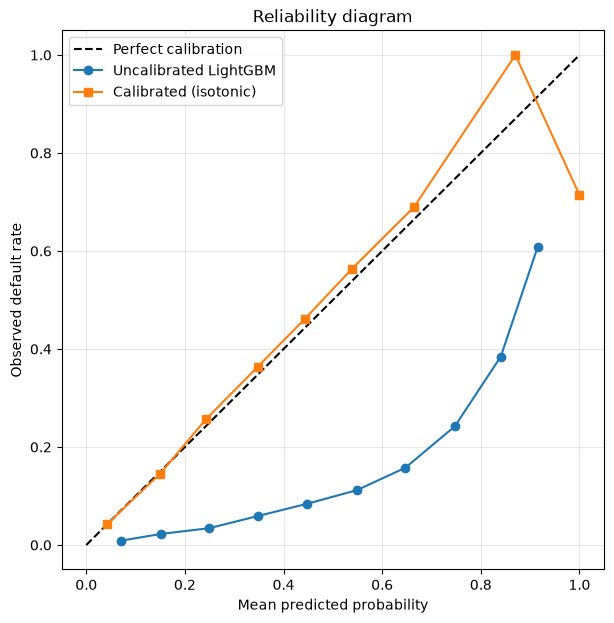

In [10]:
import os
os.makedirs("../reports", exist_ok=True)

t_uncal, p_uncal = calibration_curve(y_test, y_prob_uncal, n_bins=10)
t_cal, p_cal = calibration_curve(y_test, y_prob_cal, n_bins=10)

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
ax.plot(p_uncal, t_uncal, 'o-', label='Uncalibrated LightGBM')
ax.plot(p_cal, t_cal, 's-', label='Calibrated (isotonic)')
ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Observed default rate')
ax.set_title('Reliability diagram')
ax.legend()
ax.grid(alpha=0.3)
fig.savefig("../reports/calibration.png", dpi=150, bbox_inches='tight')
plt.show()

c:\Users\frana\anaconda3\envs\credit\Lib\site-packages\shap\explainers\_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


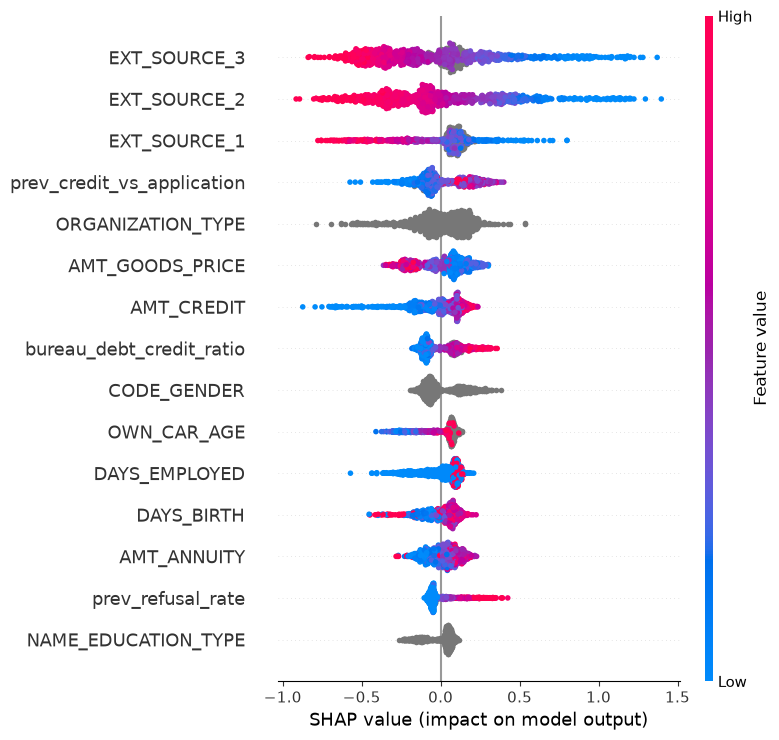

In [11]:
sample = X_test.sample(1000, random_state=42)

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(sample)

shap.summary_plot(shap_values, sample, max_display=15, show=False)
plt.tight_layout()
plt.savefig("../reports/shap_summary.png", dpi=150, bbox_inches='tight')
plt.show()

## Interpretation

### Calibration

The uncalibrated model is severely miscalibrated: at a predicted probability
of 0.75, the observed default rate is only about 0.24. The cause is
`class_weight="balanced"`, which up-weights the minority class during training
and inflates the output probabilities well above the true 8% base rate. This
helps ranking but makes the raw scores unusable as probabilities.

The Brier score makes the size of the problem concrete. Predicting the base
rate of 0.08 for every client would already score about 0.074, so the
uncalibrated model (0.16) performs *worse than a constant prediction* in
probabilistic terms, despite an AUC of 0.77. After isotonic calibration the
Brier score drops to 0.065, below the constant baseline, while the AUC is
unchanged — isotonic regression is monotonic, so it re-maps the values
without altering the ranking.

The calibrated curve tracks the diagonal closely up to roughly 0.65. Above
that it becomes erratic, but those bins contain very few clients, so the
observed rates there are dominated by sampling noise rather than real
miscalibration.

### Feature attributions

The three `EXT_SOURCE` features (normalised scores from external credit
bureaus) dominate the model by a wide margin. Their direction is as expected:
high values push the prediction towards lower risk.

Three of the aggregated features built in `src/features.py` appear in the top
fifteen, which indicates the multi-table feature engineering added genuine
signal rather than noise:

- `prev_credit_vs_application` (rank 4) — clients who previously received
  less credit than they applied for are predicted as higher risk.
- `bureau_debt_credit_ratio` (rank 8) — a higher share of outstanding debt
  relative to total credit increases predicted risk.
- `prev_refusal_rate` (rank 14) — a history of refused applications
  increases predicted risk.

`DAYS_BIRTH` and `DAYS_EMPLOYED` are stored as negative values, so lower
values mean older clients and longer employment. Both push predictions
towards lower risk, consistent with domain intuition.

### Fairness concern

`CODE_GENDER` appears among the top features and contributes materially to
individual predictions. A model that uses gender as a predictor requires
explicit fairness assessment before it could be considered for deployment —
group-wise performance and error rates need to be measured, not assumed.
This motivates the Fairlearn analysis planned as the next step.